## Dividir el sateset en conjunto de entrenamiento y de testing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
data = pd.read_csv("../datasets/ads/Advertising.csv")

In [21]:
a = np.random.randn(len(data))

(array([ 4., 15., 16., 29., 47., 40., 26., 15.,  5.,  3.]),
 array([-2.9132767 , -2.31536646, -1.71745622, -1.11954599, -0.52163575,
         0.07627449,  0.67418472,  1.27209496,  1.8700052 ,  2.46791543,
         3.06582567]),
 <a list of 10 Patch objects>)

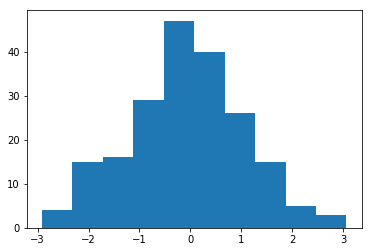

In [22]:
plt.hist(a)

In [23]:
check = (a<0.8)
training = data[check]
testing = data[~check]

In [24]:
len(training), len(testing)

(155, 45)

In [25]:
import statsmodels.formula.api as smf

In [26]:
lm = smf.ols(formula="Sales~TV+Radio", data=training).fit()

In [27]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     653.8
Date:                Sun, 26 Apr 2020   Prob (F-statistic):           2.18e-75
Time:                        12:25:27   Log-Likelihood:                -300.45
No. Observations:                 155   AIC:                             606.9
Df Residuals:                     152   BIC:                             616.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8198      0.340      8.282      0.000       2.147       3.492
TV             0.0457      0.002     28.652      0.000       0.043       0.049
Radio          0.1900      0.009     20.699      0.000       0.172       0.208
==============================================================================
Omnibus:                       54.982   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              158.640
Skew:                          -1.410   Prob(JB):                     3.56e-35
Kurtosis:                       7.076   Cond. No.                         438.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Validación dek modelo con el conjunto de testing

In [28]:
sales_pred = lm.predict(testing)
sales_pred

17     23.194880
18      9.875145
23     16.456695
25     15.490605
34      7.456084
38      9.861316
39     20.395248
41     17.249187
44      8.849301
46      8.797186
55     21.289485
58     21.870923
59     18.047112
66      8.932555
67     11.936317
68     18.886392
69     21.061855
70     17.726390
72     10.314023
82     10.115711
84     20.740143
86     11.529465
90      9.883867
105    17.933772
106     6.051556
117     6.460707
121     7.801551
125     9.044043
126    10.567425
135    13.956031
136    11.399296
140     9.401903
141    18.391847
143     8.679571
144    10.025081
156    15.373396
158    10.365502
160    14.136500
169    17.816961
174    13.622096
176    19.901760
187    17.000032
189     5.972868
193    18.417490
196     8.052626
dtype: float64

In [29]:
SSD = sum((testing["Sales"] - sales_pred)**2)
SSD

119.98637046908384

In [30]:
RSE = np.sqrt(SSD/(len(testing)-2-1))
RSE

1.6902125145974978

In [31]:
sales_mean = np.mean(testing["Sales"])
error = RSE/sales_mean
error

0.12192940550959826